# Bank Customer Churn — Final Business Analysis

## Objective

This notebook consolidates the key findings from customer analysis and churn analysis to identify:

- The bank's most valuable customer segments
- The customer groups contributing most to churn
- High-value customers who are at risk of leaving
- Key business problems affecting customer retention
- Actionable strategies to improve customer retention and customer value

The objective is to translate analytical findings into practical business recommendations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("../data/cleaned/bank_customer_churn_cleaned.csv")

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  str    
 3   Gender           10000 non-null  str    
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(2)
memory usage: 937.6 KB


## Overall Business Performance

In [5]:
total_customers = data["CustomerId"].nunique()

churned_customers = data.loc[data["Exited"] == 1, "CustomerId"].nunique()

active_customers = data.loc[data["Exited"] == 0, "CustomerId"].nunique()

churn_rate = churned_customers / total_customers * 100

print("Total Customers:", total_customers)
print("Active Customers:", active_customers)
print("Churned Customers:", churned_customers)
print("Overall Churn Rate:", round(churn_rate, 2), "%")

Total Customers: 10000
Active Customers: 7963
Churned Customers: 2037
Overall Churn Rate: 20.37 %


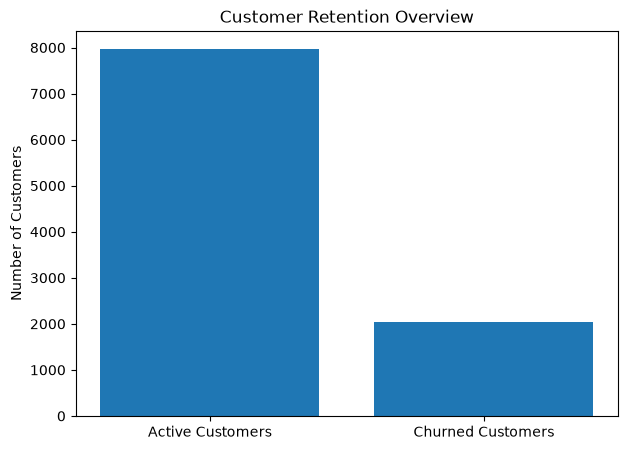

In [6]:
customer_status = data["Exited"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Active Customers", "Churned Customers"],
    [customer_status[0], customer_status[1]]
)

plt.title("Customer Retention Overview")
plt.ylabel("Number of Customers")
plt.show()

### Business Interpretation

The bank has a significantly larger active customer base than churned customer base. However, the churned customer segment represents a meaningful proportion of the customer base and therefore requires targeted retention strategies.

The objective should not be to treat every customer equally. Instead, the bank should identify customers who combine high customer value with high churn risk.

## Product Relationship & Customer Value

In [7]:
customer_value = data.groupby("NumOfProducts").agg(
    customers=("CustomerId", "nunique"),
    avg_balance=("Balance", "mean"),
    avg_salary=("EstimatedSalary", "mean"),
    churn_rate=("Exited", "mean")
).reset_index()

customer_value["churn_rate"] = customer_value["churn_rate"] * 100

customer_value

,NumOfProducts,customers,avg_balance,avg_salary,churn_rate
0,1,5084,98551.870614,99487.256851,27.714398
1,2,4590,51879.145813,100452.012821,7.581699
2,3,266,75458.328195,104318.130564,82.706767
3,4,60,93733.135000,104763.723333,100.000000


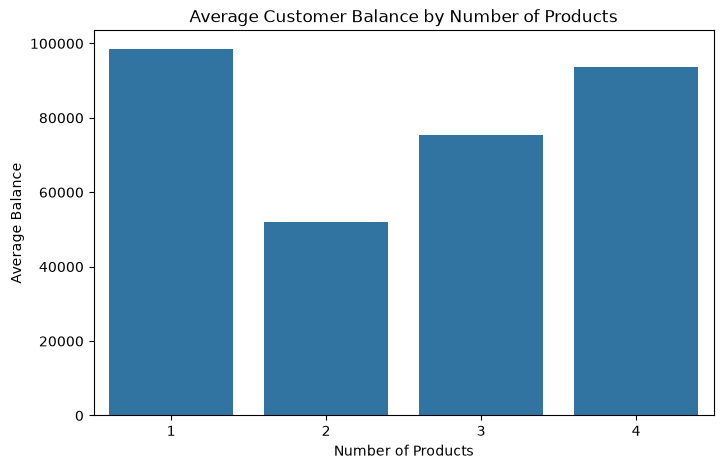

In [8]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=customer_value,
    x="NumOfProducts",
    y="avg_balance"
)

plt.title("Average Customer Balance by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Average Balance")
plt.show()

### Business Interpretation

Customer value differs across product groups. Customers holding more banking products can represent stronger relationships with the bank, but product count alone should not be considered a measure of customer value.

Customer balance, activity level, and churn risk should be considered together when prioritizing retention efforts.

## Customer Active Member Analysis

In [9]:
activity_analysis = data.groupby("IsActiveMember").agg(
    customers=("CustomerId", "nunique"),
    churned_customers=("Exited", "sum"),
    churn_rate=("Exited", "mean")
).reset_index()

activity_analysis["churn_rate"] = activity_analysis["churn_rate"] * 100

activity_analysis

,IsActiveMember,customers,churned_customers,churn_rate
0,0,4849,1302,26.850897
1,1,5151,735,14.269074


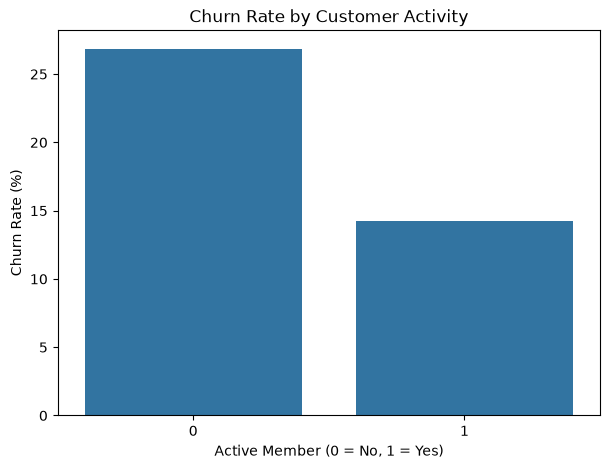

In [10]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=activity_analysis,
    x="IsActiveMember",
    y="churn_rate"
)

plt.title("Churn Rate by Customer Activity")
plt.xlabel("Active Member (0 = No, 1 = Yes)")
plt.ylabel("Churn Rate (%)")
plt.show()

### Business Interpretation

Customer engagement is strongly relevant to retention. Customers who are less active with the bank show a higher tendency to leave.

This suggests that improving customer engagement can be an important component of the bank's retention strategy.

## Geography & Churn

In [11]:
geography_analysis = data.groupby("Geography").agg(
    customers=("CustomerId", "nunique"),
    churned_customers=("Exited", "sum"),
    churn_rate=("Exited", "mean"),
    avg_balance=("Balance", "mean")
).reset_index()

geography_analysis["churn_rate"] = geography_analysis["churn_rate"] * 100

geography_analysis.sort_values(
    "churn_rate",
    ascending=False
)

,Geography,customers,churned_customers,churn_rate,avg_balance
1,Germany,2509,814,32.443204,119730.116134
2,Spain,2477,413,16.673395,61818.147763
0,France,5014,810,16.154767,62092.636516


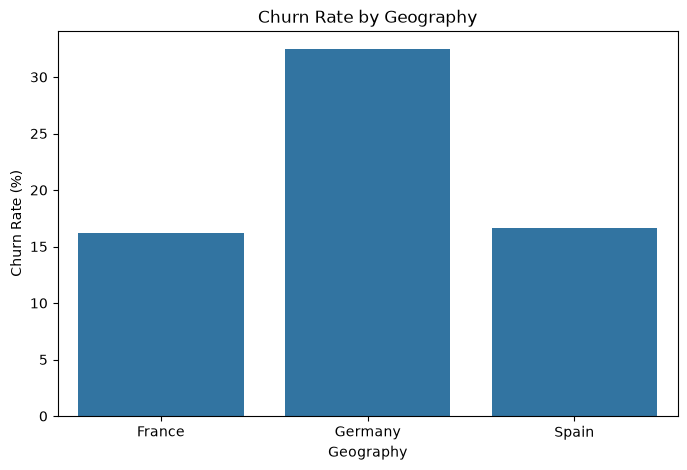

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=geography_analysis,
    x="Geography",
    y="churn_rate"
)

plt.title("Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.show()

### Business Interpretation

Churn varies across geographic markets. Therefore, retention strategies should not necessarily be identical across all regions.

Markets with higher churn rates should receive additional investigation to understand whether differences in customer behavior, engagement, product usage, or service experience are contributing to customer attrition.

## Age Segment Analysis

In [13]:
data["AgeGroup"] = pd.cut(
    data["Age"],
    bins=[17, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

In [14]:
age_analysis = data.groupby("AgeGroup", observed=True).agg(
    customers=("CustomerId", "nunique"),
    churned_customers=("Exited", "sum"),
    churn_rate=("Exited", "mean"),
    avg_balance=("Balance", "mean")
).reset_index()

age_analysis["churn_rate"] = age_analysis["churn_rate"] * 100

age_analysis

,AgeGroup,customers,churned_customers,churn_rate,avg_balance
0,18-30,1968,148,7.520325,73198.764050
1,31-40,4451,538,12.087171,75583.362420
2,41-50,2320,788,33.965517,79122.193461
3,51-60,797,448,56.210790,82401.663162
4,60+,464,115,24.784483,75742.596401


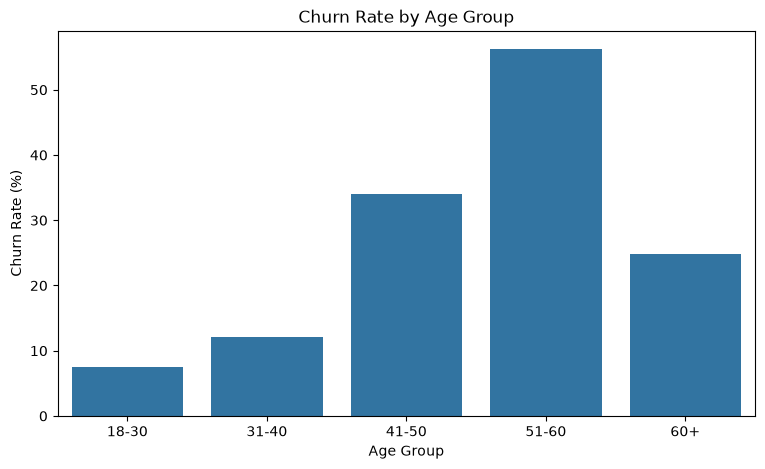

In [15]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_analysis,
    x="AgeGroup",
    y="churn_rate"
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.show()

## Credit Score & Churn

In [16]:
data["CreditScoreGroup"] = pd.cut(
    data["CreditScore"],
    bins=[0, 579, 669, 739, 799, 900],
    labels=[
        "Poor",
        "Fair",
        "Good",
        "Very Good",
        "Excellent"
    ]
)

In [17]:
credit_analysis = data.groupby(
    "CreditScoreGroup",
    observed=True
).agg(
    customers=("CustomerId", "nunique"),
    churned_customers=("Exited", "sum"),
    churn_rate=("Exited", "mean")
).reset_index()

credit_analysis["churn_rate"] = credit_analysis["churn_rate"] * 100

credit_analysis

,CreditScoreGroup,customers,churned_customers,churn_rate
0,Poor,2362,520,22.015241
1,Fair,3331,685,20.564395
2,Good,2428,452,18.616145
3,Very Good,1224,252,20.588235
4,Excellent,655,128,19.541985


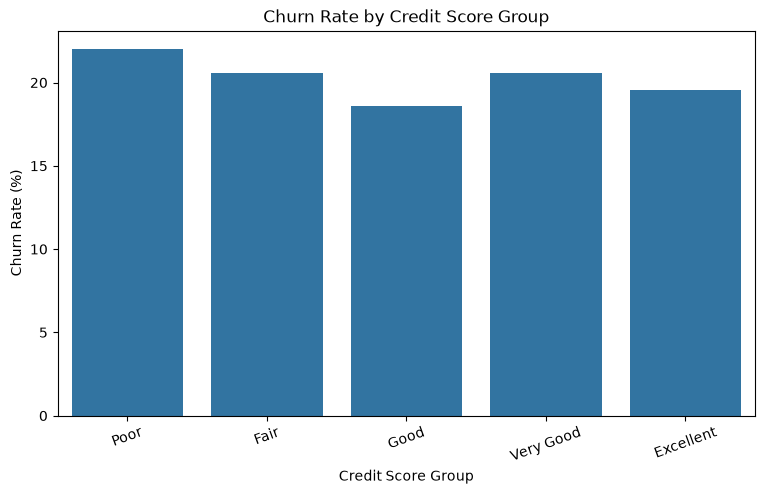

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=credit_analysis,
    x="CreditScoreGroup",
    y="churn_rate"
)

plt.title("Churn Rate by Credit Score Group")
plt.xlabel("Credit Score Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.show()

## High-Value & High-Risk Customers

In [19]:
balance_threshold = data["Balance"].quantile(0.75)

high_value_churned = data[
    (data["Balance"] >= balance_threshold) &
    (data["Exited"] == 1)
].copy()

print("High-value churned customers:", len(high_value_churned))

High-value churned customers: 592


In [20]:
high_value_churned[
    [
        "CustomerId",
        "Geography",
        "Age",
        "Balance",
        "NumOfProducts",
        "IsActiveMember",
        "EstimatedSalary",
        "Exited"
    ]
].head(10)

,CustomerId,Geography,Age,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited
2,15619304,France,42,159660.80,3,0,113931.57,1
16,15737452,Germany,58,132602.88,1,0,5097.67,1
35,15794171,France,45,134264.04,1,0,27822.99,1
43,15755196,France,49,131394.56,1,0,194365.76,1
47,15771573,Germany,39,137843.80,1,1,117622.80,1
70,15703793,Germany,58,133745.44,4,0,28373.86,1
114,15609618,Germany,28,154475.54,2,1,101300.94,1
125,15627360,France,42,152603.45,1,0,110265.24,1
127,15782688,Germany,56,148507.24,1,0,46824.08,1
138,15594408,Spain,48,213146.20,1,0,75161.25,1


## High-Value Customer Churn Rate

In [24]:
high_value_customers = data[
    data["Balance"] >= balance_threshold
]

high_value_churn_rate = (
    high_value_customers["Exited"].mean() * 100
)

overall_churn_rate = data["Exited"].mean() * 100

print(
    "Overall Churn Rate:",
    round(overall_churn_rate, 2), "%"
)

print(
    "High-Value Customer Churn Rate:",
    round(high_value_churn_rate, 2), "%"
)

Overall Churn Rate: 20.37 %
High-Value Customer Churn Rate: 23.68 %


### Business Interpretation

High-value customers require particular attention because losing a customer with a large account balance can have a greater financial impact than losing a lower-value customer.

The bank should therefore prioritize retention efforts toward high-value customers who also exhibit characteristics associated with churn.

## Customer Risk Segment

In [26]:
data["HighBalance"] = (
    data["Balance"] >= data["Balance"].quantile(0.75)
)

data["Inactive"] = data["IsActiveMember"] == 0

data["RiskSegment"] = np.select(
    [
        (data["HighBalance"]) & (data["Inactive"]) & (data["Exited"] == 1),
        (data["HighBalance"]) & (data["Inactive"]),
        (data["Exited"] == 1),
        (data["Inactive"])
    ],
    [
        "High-Value Churned",
        "High-Value Inactive",
        "Churned",
        "Inactive"
    ],
    default="Active"
)

data["RiskSegment"].value_counts()

RiskSegment
Active                 4416
Inactive               2680
Churned                1657
High-Value Inactive     867
High-Value Churned      380
Name: count, dtype: int64

In [ ]:
risk_segment = data["RiskSegment"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=risk_segment.index,
    y=risk_segment.values
)

plt.title("Customer Risk Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

# Key Business Findings

### 1. Customer Churn Is a Significant Retention Challenge

The bank has **10,000 customers**, of whom **2,037 have churned**, resulting in an overall churn rate of **20.37%**.

Although the majority of customers are retained, approximately **1 in 5 customers has exited**, making customer retention an important business priority.

---

### 2. Germany Has the Highest Churn Rate

Churn varies considerably across the three geographic markets.

* **Germany:** 32.44% churn rate
* **Spain:** 16.67% churn rate
* **France:** 16.15% churn rate

Germany therefore stands out as the highest-churn market and should be prioritized for deeper investigation and targeted retention strategies.

---

### 3. Customer Engagement Is Strongly Associated with Retention

Inactive members have a churn rate of **26.85%**, compared with **14.27%** among active members.

This represents a substantial difference in churn behavior and indicates that customer engagement is an important retention signal.

The bank should therefore monitor declining customer activity as a potential early-warning indicator.

---

### 4. Product Relationship Shows a Strong Difference in Churn

Customers holding two products have a relatively low churn rate of **7.58%**, while customers with three products have a churn rate of **82.71%**.

Customers with four products show a **100% churn rate**, but this group contains only **60 customers**, so the result should be interpreted cautiously because of the small sample size.

The analysis therefore suggests that product count is an important segmentation variable, but extreme product groups should not be interpreted without considering segment size.

---

### 5. Higher-Balance Customers Require Attention

Customers in the **100K–150K balance group** have a churn rate of **25.77%**, compared with **14.25%** among customers with balances below 50K.

The 200K+ group shows a churn rate of **55.88%**, but it contains only **34 customers**, so this result should be treated as directional rather than conclusive.

Overall, higher-balance customers should receive greater attention because their departure may represent a greater potential business impact.

---

### 6. High-Value Customers Have Above-Average Churn

High-value customers, defined using the **top 25% of customers by account balance**, have a churn rate of **23.68%**, compared with the overall churn rate of **20.37%**.

This indicates that the bank is not only losing customers, but also losing some customers from a strategically important value segment.

Retention efforts should therefore prioritize high-value customers who also display other risk characteristics.

---

### 7. Churn Is Not Uniform Across Customer Segments

The analysis shows that churn differs across:

* Geography
* Age groups
* Customer activity
* Product holdings
* Account balance
* Credit-score groups
* Combined customer segments

This indicates that a single retention strategy is unlikely to be equally effective for the entire customer base.

---

### 8. The Most Important Business Opportunity Is Targeted Retention

The analysis supports moving from broad customer retention toward **targeted intervention**.

Customers combining characteristics such as **high account balance, inactivity, and elevated churn risk** should receive the highest retention priority.

These findings should be treated as **associations identified through exploratory analysis, not proof of causation**.


# Business Recommendations

## 1. Prioritize High-Value At-Risk Customers

The bank should create a dedicated retention strategy for customers who combine **high account balance with elevated churn risk**.

High-value customers have a **23.68% churn rate**, above the overall rate of 20.37%.

### Recommended actions:

* Proactive relationship-manager outreach
* Personalized retention offers
* Preferential banking services
* Personalized financial-product recommendations
* Early intervention before the customer exits

The objective should be to protect customers with both high value and high retention risk.

---

## 2. Build an Engagement-Based Early Warning System

Inactive members have a **26.85% churn rate**, compared with **14.27% among active members**.

The bank should therefore monitor customer engagement and identify customers whose activity is declining.

### Recommended actions:

* Track declining account activity
* Send personalized financial insights
* Encourage digital banking engagement
* Provide relevant product recommendations
* Introduce loyalty and engagement campaigns

Inactive status should be treated as a **risk signal**, not as proof that a customer will churn.

---

## 3. Investigate Germany as a Priority Market

Germany has a **32.44% churn rate**, substantially higher than France and Spain.

The bank should conduct a deeper market-level investigation to understand whether the difference is related to:

* Customer experience
* Product fit
* Engagement
* Service quality
* Customer demographics
* Regional banking preferences

Retention initiatives in Germany should be evaluated separately rather than applying exactly the same strategy used in France and Spain.

---

## 4. Review Product Relationships Before Expanding Cross-Selling

Product count shows substantial differences in churn.

Customers with two products have a **7.58% churn rate**, while customers with three products have an **82.71% churn rate**.

The bank should therefore avoid assuming that more products automatically mean higher customer value or stronger loyalty.

### Recommended actions:

* Investigate why customers with three or four products show unusually high churn
* Review product combinations and customer experience
* Identify potentially unsuitable product bundles
* Use needs-based cross-selling rather than simply increasing product count

The four-product segment contains only 60 customers, so its 100% churn rate should not be treated as a stable population-level estimate.

---

## 5. Protect Customers with Higher Account Balances

Customers with balances between **100K and 150K have a 25.77% churn rate**, compared with 14.25% for customers below 50K.

The bank should identify high-balance customers who also show inactivity or other elevated-risk characteristics.

### Recommended actions:

* Dedicated retention outreach
* Personalized financial services
* Relationship-manager monitoring
* Early-warning alerts for high-value customers

---

## 6. Develop Segment-Specific Retention Strategies

The analysis demonstrates that churn is not evenly distributed across the customer base.

The bank should therefore segment retention programs by characteristics such as:

* Geography
* Age
* Activity level
* Product holdings
* Account balance
* Credit profile

Different customer groups should receive different interventions based on their observed behavior.

---

## 7. Establish a Churn Monitoring Dashboard

The bank should continuously monitor key retention KPIs rather than analyzing churn only periodically.

### Recommended KPIs:

* Overall churn rate
* Churned customers
* Churn rate by geography
* Churn rate by activity status
* Churn rate by product count
* Churn rate by balance group
* High-value customer churn
* High-risk customer population

This would allow management to identify emerging risk segments and evaluate whether retention initiatives are improving customer outcomes.

---

## 8. Move Toward Predictive Churn Modeling

The exploratory analysis identifies several customer characteristics associated with churn.

As a next step, the bank could develop a predictive churn model to estimate the probability that an individual customer will leave.

Potential inputs could include:

* Age
* Geography
* Tenure
* Balance
* Number of products
* Credit score
* Active-member status
* Credit-card ownership
* Estimated salary

The predictive model should complement, rather than replace, the business analysis performed in this project.


## Project Summary

This project analyzed **10,000 bank customers** to understand customer characteristics, customer behavior, and churn patterns and to translate those findings into actionable business recommendations.

The analysis identified an overall churn rate of **20.37%**, with **2,037 customers having exited the bank**.

Several customer segments showed materially different churn behavior. **Germany recorded the highest geographic churn rate at 32.44%**, while inactive members had a churn rate of **26.85% compared with 14.27% among active members**.

Product relationships also showed substantial variation. Customers with two products had a relatively low churn rate of **7.58%**, whereas customers with three products had an **82.71% churn rate**. The four-product segment reached 100%, but its small population of 60 customers means this result should be interpreted cautiously.

The analysis also identified a strategically important value-risk relationship. Customers in the high-value segment had a churn rate of **23.68%**, above the overall churn rate of 20.37%.

### Overall Business Takeaway

The key business challenge is not simply the number of customers who churn, but **identifying which customers are most important and most at risk of leaving**.

The strongest opportunity is therefore to combine **customer value, engagement, geography, product relationship, and demographic characteristics** to prioritize retention efforts.
